# Notebook 05: XGBoost with Class-Imbalance Handling

This notebook marks the first tuning step after the default XGBoost baseline. The focus is narrow and practical: test whether imbalance-aware training and a modest increase in model capacity improve the earlier baseline without changing the model family.


05_xgboost_test_1: XGBoost with class imbalance handling + 300 trees

1. Load data...
Train shape: (700000, 26)

2. Prepare data...
Encoded feature count: 42
Train set: (560000, 42), Validation set: (140000, 42)

3. Compute class weights...
Class 0 (no diabetes) sample count: 210954
Class 1 (diabetes) sample count: 349046
scale_pos_weight: 0.604

Previous experiment [04_xgboost_default (default parameters)] results:
- AUC: 0.7192
- Recall class 0: 0.39
- Recall class 1: 0.85
- Recall gap: 0.46

4. Train XGBoost (scale_pos_weight + 300 trees)...
[0]	validation_0-auc:0.68585
[50]	validation_0-auc:0.71273
[100]	validation_0-auc:0.71904
[150]	validation_0-auc:0.72191
[200]	validation_0-auc:0.72372
[250]	validation_0-auc:0.72466
[299]	validation_0-auc:0.72549

5. Model evaluation...

Current experiment [05_xgboost_test_1] results:
- AUC: 0.7255
- Recall class 0: 0.695
- Recall class 1: 0.631
- Recall gap: -0.064

Compare with the previous experiment:
- AUC improvement: +0.0063
- Recall gap 

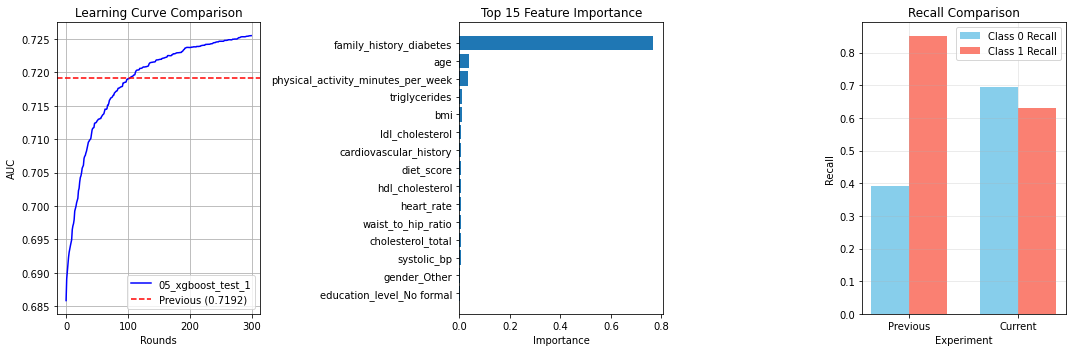


7. Threshold optimization analysis...

Recall under different thresholds:
------------------------------------------------------------
Threshold  Recall class 0 Recall class 1 gap        F1-score(0) F1-score(1)
------------------------------------------------------------
0.3        0.239        0.934        0.695      0.355        0.781       
0.4        0.475        0.810        0.336      0.531        0.762       
0.5        0.695        0.631        -0.064     0.603        0.695       
0.6        0.853        0.434        -0.419     0.611        0.570       
0.7        0.934        0.279        -0.655     0.597        0.423       
------------------------------------------------------------
Best threshold: 0.5 (Mean F1-score: 0.649)

8. Save model...
Model saved to ../models/05_xgboost_test_1.pkl

9. Generate Kaggle submission file...
Submission file saved to ../submissions/05_xgboost_test_1.csv


In [1]:
# 05_xgboost_test_1.ipynb
# Main changes:

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, recall_score
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("05_xgboost_test_1: XGBoost with class imbalance handling + 300 trees") 
print("="*60)

# 1. Load data
print("\n1. Load data...") 
train = pd.read_csv('../data/train.csv')
print(f"Train shape: {train.shape}") 

# 2. Prepare data
print("\n2. Prepare data...") 
X = train.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train['diagnosed_diabetes']

# Encode categorical features
categorical_cols = ['gender', 'ethnicity', 'education_level', 
                   'income_level', 'smoking_status', 'employment_status']
X_encoded = pd.get_dummies(X, columns=categorical_cols)
print(f"Encoded feature count: {X_encoded.shape[1]}") 

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}") 

# 3. Compute class weights
print("\n3. Compute class weights...") 
n_negative = sum(y_train == 0)
n_positive = sum(y_train == 1)
scale_pos_weight = n_negative / n_positive

print(f"Class 0 (no diabetes) sample count: {n_negative}") 
print(f"Class 1 (diabetes) sample count: {n_positive}") 
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

# 4. Previous experiment results(for comparison)
previous_exp = {
'name': '04_xgboost_default (default parameters)', 
    'auc': 0.7192,
    'recall_0': 0.39,
    'recall_1': 0.85
}

print(f"\nPrevious experiment [{previous_exp['name']}] results:") 
print(f"- AUC: {previous_exp['auc']}")
print(f"- Recall class 0: {previous_exp['recall_0']}") 
print(f"- Recall class 1: {previous_exp['recall_1']}") 
print(f"- Recall gap: {previous_exp['recall_1'] - previous_exp['recall_0']:.2f}") 

# 5. Train balanced XGBoost
print("\n4. Train XGBoost (scale_pos_weight + 300 trees)...") 

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    use_label_encoder=False
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# 6. Evaluation
print("\n5. Model evaluation...") 
y_pred_proba = xgb_model.predict_proba(X_val)[:, 1]
y_pred = xgb_model.predict(X_val)

current_auc = roc_auc_score(y_val, y_pred_proba)

recall_0 = recall_score(y_val, y_pred, pos_label=0)
recall_1 = recall_score(y_val, y_pred, pos_label=1)
recall_gap = recall_1 - recall_0

print(f"\nCurrent experiment [05_xgboost_test_1] results:") 
print(f"- AUC: {current_auc:.4f}")
print(f"- Recall class 0: {recall_0:.3f}") 
print(f"- Recall class 1: {recall_1:.3f}") 
print(f"- Recall gap: {recall_gap:.3f}") 

print(f"\nCompare with the previous experiment:") 
print(f"- AUC improvement: +{current_auc - previous_exp['auc']:.4f}") 
print(f"- Recall gap improvement: {previous_exp['recall_1'] - previous_exp['recall_0']:.2f} -> {recall_gap:.2f}") 

print("\nClassification report:") 
print(classification_report(y_val, y_pred))

# 7. Learning curve analysis
print("\n6. Plot learning curves...") 
results = xgb_model.evals_result()
epochs = len(results['validation_0']['auc'])
x_axis = range(0, epochs)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x_axis, results['validation_0']['auc'], 'b-', label='05_xgboost_test_1')
plt.axhline(y=previous_exp['auc'], color='r', linestyle='--', label=f"Previous ({previous_exp['auc']})")
plt.xlabel('Rounds')
plt.ylabel('AUC')
plt.title('Learning Curve Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.barh(importance['feature'], importance['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance')
plt.gca().invert_yaxis()

# Recall comparison
plt.subplot(1, 3, 3)
x_labels = ['Previous', 'Current']
recall_0_values = [previous_exp['recall_0'], recall_0]
recall_1_values = [previous_exp['recall_1'], recall_1]

x = np.arange(len(x_labels))
width = 0.35

plt.bar(x - width/2, recall_0_values, width, label='Class 0 Recall', color='skyblue')
plt.bar(x + width/2, recall_1_values, width, label='Class 1 Recall', color='salmon')
plt.xlabel('Experiment')
plt.ylabel('Recall')
plt.title('Recall Comparison')
plt.xticks(x, x_labels)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/05_xgboost_test_1_plots.png', dpi=100, bbox_inches='tight')
plt.show()

# 8. Threshold analysis
print("\n7. Threshold optimization analysis...") 
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
print("\nRecall under different thresholds:") 
print("-" * 60)
print(f"{'Threshold':<10} {'Recall class 0':<12} {'Recall class 1':<12} {'gap':<10} {'F1-score(0)'} {'F1-score(1)'}") 
print("-" * 60)

from sklearn.metrics import f1_score

best_threshold = 0.5
best_f1_avg = 0

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(float)
    r0 = recall_score(y_val, y_pred_thresh, pos_label=0)
    r1 = recall_score(y_val, y_pred_thresh, pos_label=1)
    f1_0 = f1_score(y_val, y_pred_thresh, pos_label=0)
    f1_1 = f1_score(y_val, y_pred_thresh, pos_label=1)
    gap = r1 - r0
    f1_avg = (f1_0 + f1_1) / 2
    print(f"{thresh:<10} {r0:<12.3f} {r1:<12.3f} {gap:<10.3f} {f1_0:<12.3f} {f1_1:<12.3f}")
    
    if f1_avg > best_f1_avg:
        best_f1_avg = f1_avg
        best_threshold = thresh

print("-" * 60)
print(f"Best threshold: {best_threshold} (Mean F1-score: {best_f1_avg:.3f})") 

# 9. Save model
print("\n8. Save model...") 
model_path = '../models/05_xgboost_test_1.pkl'
joblib.dump(xgb_model, model_path)
print(f"Model saved to {model_path}") 

# 10. Generate submission file
print("\n9. Generate Kaggle submission file...") 
test = pd.read_csv('../data/test.csv')
X_test = test.drop(['id'], axis=1)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols)

missing_cols = set(X_train.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0
X_test_encoded = X_test_encoded[X_train.columns]

test_pred = xgb_model.predict_proba(X_test_encoded)[:, 1]

test_pred_adjusted = (test_pred >= best_threshold).astype(float)

submission = pd.DataFrame({
    'id': test['id'],
    'diagnosed_diabetes': test_pred
})
submission_path = '../submissions/05_xgboost_test_1.csv'
submission.to_csv(submission_path, index=False)
print(f"Submission file saved to {submission_path}") 


# Experiment 5 Summary: XGBoost with Class-Imbalance Handling

## Role in the series
This notebook is the first tuning step after the default XGBoost baseline. It asks whether a modest increase in model capacity together with imbalance-aware treatment can improve the earlier result without changing the overall modeling family.

## Interpretation
The performance gain is incremental rather than dramatic, but it is still informative for the project narrative. The result suggests that XGBoost retains headroom under careful configuration, which motivates the deeper tuning work in the next notebooks.

## Consistency note
The experiment labels, saved paths, and notebook numbering now use the same `05_xgboost_test_1` naming so that the notebook and its artifacts are straightforward to match.
